In [1]:
from auto_robot_design.generator.branch_generator.updated_generator import Generator2DRotational, GeneratorConnection
from auto_robot_design.generator.branch_generator.graph_scheme import MutationType, MutationCoordinate, SchemeEE, SchemeJoint, SchemeConnectionJoint
import networkx as nx
from auto_robot_design.description.kinematics import JointPoint
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from auto_robot_design.generator.branch_generator.graph_manager import MutableGraphManager
from auto_robot_design.description.utils import draw_joint_point

2


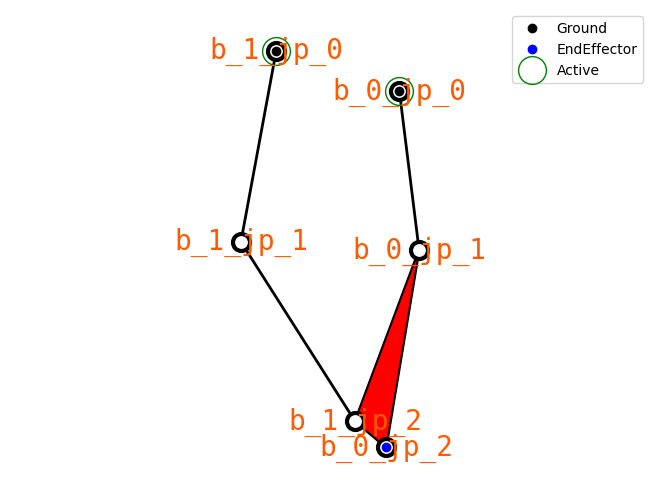

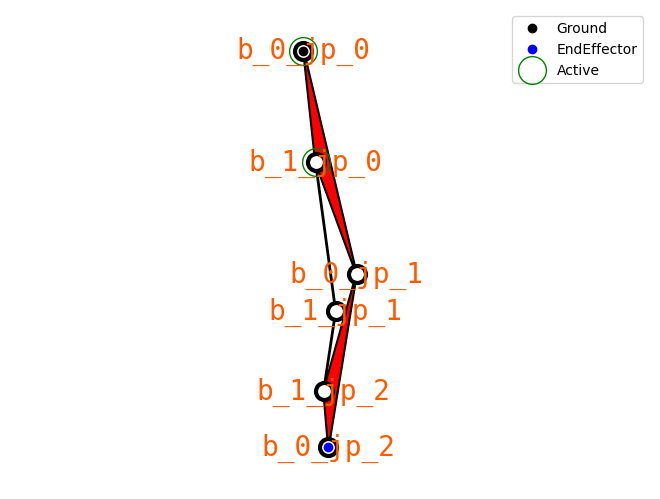

In [8]:
generator = Generator2DRotational()
joint = SchemeJoint(name="b_0_j_0", mutation_type=MutationType.ABSOLUTE, mutation_x=MutationCoordinate(
    freeze=0.0), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(freeze=0.0), active=True, attach_ground=True)
generator.add_joint(joint)
joint = SchemeJoint(name="b_0_j_1", mutation_type=MutationType.ABSOLUTE,
                    mutation_x=MutationCoordinate(mutation_origin=0.05, lower_bound=-0.1, upper_bound=0.1), mutation_y = MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.2, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(joint)
ee = SchemeEE(name="b_0_j_2", mutation_x=MutationCoordinate(mutation_origin=0.0, lower_bound=-0.1, upper_bound=0.1), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.4, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(ee)

scheme_connection = SchemeConnectionJoint(name="G",
                                            mutation_type=MutationType.ABSOLUTE,
                                            mutation_x = MutationCoordinate(mutation_origin=-0.2, upper_bound=0.1, lower_bound=-0.1), 
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=0.0, upper_bound=0.2),
                                        active=False, attach_ground=True, connected_to=(0,-1))
connection = GeneratorConnection(scheme_connection, start_open=([1]), end_open=(), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="CJ_0",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE,
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(0, 0))
connection = GeneratorConnection(scheme_connection, start_open=([1]), end_open=(), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="CJ_1",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE, 
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(0, 1))
connection = GeneratorConnection(scheme_connection, start_open=(), end_open=([1]), connected=None)
generator.add_connection(connection)

generator.create_sub_branch()
joint = SchemeJoint(name="b_1_j_0", mutation_type=MutationType.RELATIVE, mutation_x=MutationCoordinate(mutation_origin=0.0, lower_bound=-0.1, upper_bound=0.1), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.2, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(joint, 1)


generator.build_all_topologies()
print(len(generator.topologies))

for topology in generator.topologies:
    manager = MutableGraphManager(topology)
    manager.build_graph()
    manager.get_mutation_ranges()
    graph = manager.get_random_graph()
    manager.find_active_joints()
    patches = []
    for triangle in manager.triangle_links:
        patches.append([triangle,"#FF0000"])
    draw_joint_point(graph, patches_list=patches)
    plt.show()

In [2]:
generator = Generator2DRotational()
joint = SchemeJoint(name="b_0_j_0", mutation_type=MutationType.ABSOLUTE, mutation_x=MutationCoordinate(
    freeze=0.0), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(freeze=0.0), active=True, attach_ground=True)
generator.add_joint(joint)
joint = SchemeJoint(name="b_0_j_1", mutation_type=MutationType.ABSOLUTE,
                    mutation_x=MutationCoordinate(mutation_origin=0.05, lower_bound=-0.1, upper_bound=0.1), mutation_y = MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.2, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(joint)
ee = SchemeEE(name="b_0_j_2", mutation_x=MutationCoordinate(mutation_origin=0.0, lower_bound=-0.1, upper_bound=0.1), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.4, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(ee)

scheme_connection = SchemeConnectionJoint(name="G",
                                            mutation_type=MutationType.ABSOLUTE,
                                            mutation_x = MutationCoordinate(mutation_origin=-0.2, upper_bound=0.1, lower_bound=-0.1), 
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=0.0, upper_bound=0.2),
                                        active=False, attach_ground=True, connected_to=(0,-1))
connection = GeneratorConnection(scheme_connection, start_open=(1,2), end_open=(), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="CJ_0",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE,
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(0, 0), dependent_shift=[-0.05, 0.0, 0.0])
connection = GeneratorConnection(scheme_connection, start_open=(1,2), end_open=tuple([1]), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="CJ_1",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE, 
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(0, 1))
connection = GeneratorConnection(scheme_connection, start_open=tuple([2]), end_open=(1,2), connected=None)
generator.add_connection(connection)

13


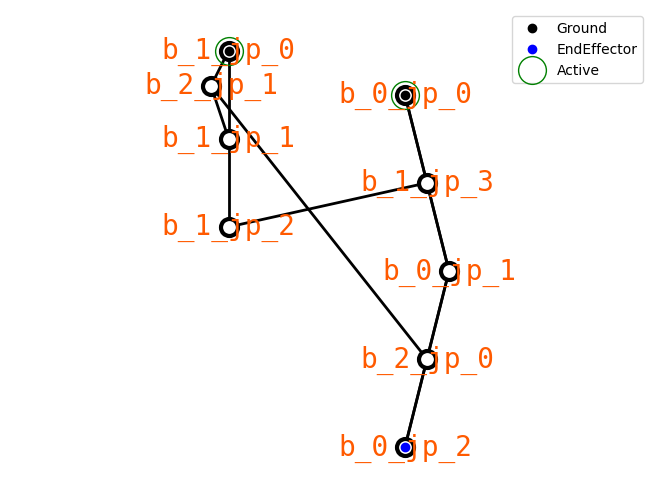

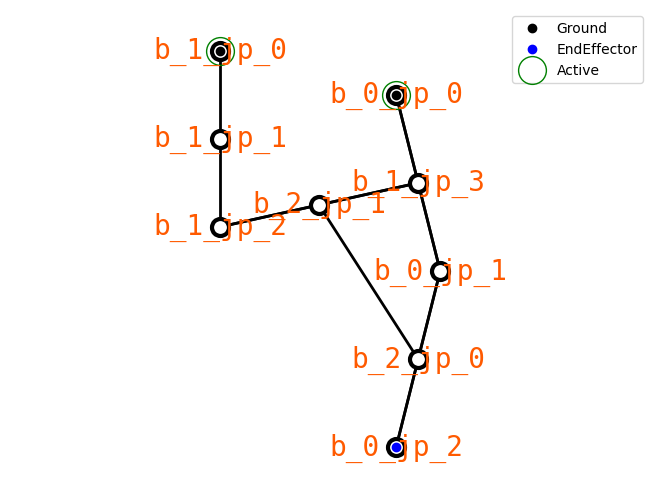

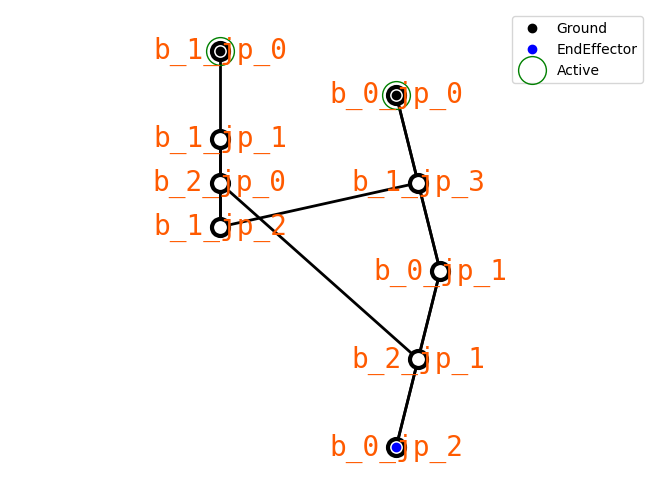

Triangle cycle detected in topology
Triangle cycle detected in topology


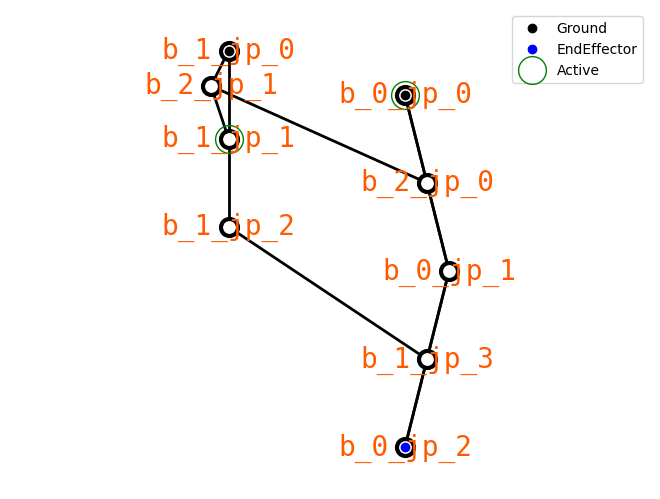

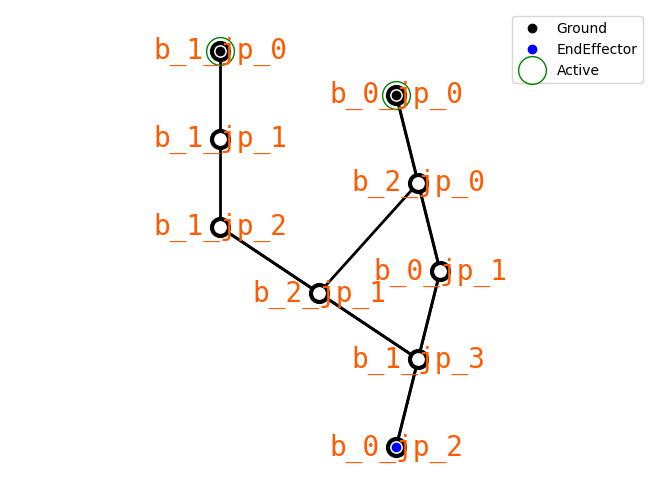

Triangle cycle detected in topology
Triangle cycle detected in topology


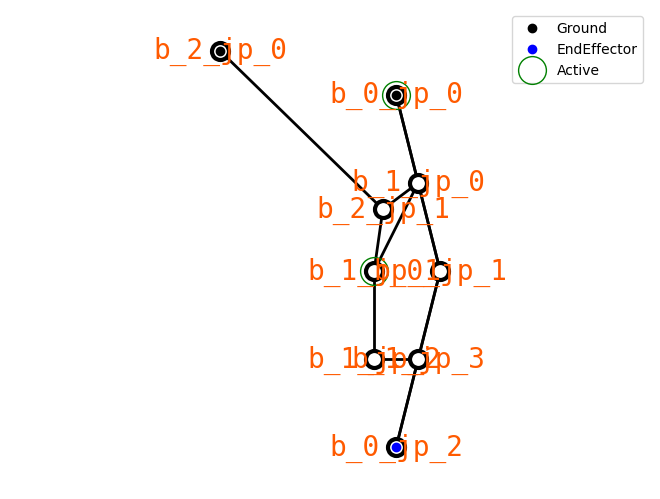

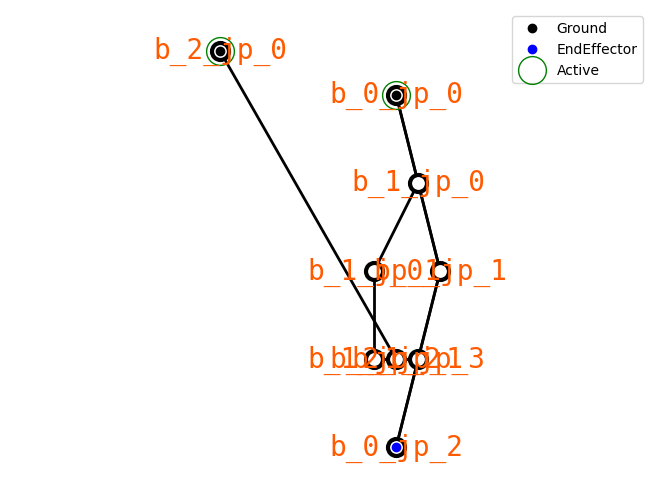

Triangle cycle detected in topology
Triangle cycle detected in topology


In [3]:
generator.create_sub_branch()
joint = SchemeJoint(name="b_1_j_1", mutation_type=MutationType.RELATIVE, mutation_x=MutationCoordinate(mutation_origin=0.0, lower_bound=-0.1, upper_bound=0.1), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.1, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(joint, 1)
joint = SchemeJoint(name="b_1_j_2", mutation_type=MutationType.RELATIVE, mutation_x=MutationCoordinate(mutation_origin=0.0, lower_bound=-0.1, upper_bound=0.1), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.1, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(joint, 1)

scheme_connection = SchemeConnectionJoint(name="BC_0",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE,
                                            mutation_x = MutationCoordinate(mutation_origin=-0.2, upper_bound=0.1, lower_bound=-0.1), 
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=0.0, upper_bound=0.2),
                                        active=False, attach_ground=False, connected_to=(1,0))
connection = GeneratorConnection(scheme_connection, start_open=(), end_open=tuple([2]), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="BC_1",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE,
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(1, 1), dependent_shift=[-0.05, 0.0, 0.0])
connection = GeneratorConnection(scheme_connection, start_open=tuple([2]), end_open=(), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="BC_2",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE, 
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(1, 2))
connection = GeneratorConnection(scheme_connection, start_open=(), end_open=tuple([2]), connected=None)
generator.add_connection(connection)

generator.create_sub_branch()

generator.build_all_topologies()
print(len(generator.topologies))

for topology in generator.topologies:
    manager = MutableGraphManager(topology)
    manager.build_graph()
    if manager.check_for_triangle_cycles():
        print("Triangle cycle detected in topology")
        continue
    manager.find_active_joints()
    manager.get_mutation_ranges()
    graph = manager.get_central_graph()
    draw_joint_point(graph)
    plt.show()


20


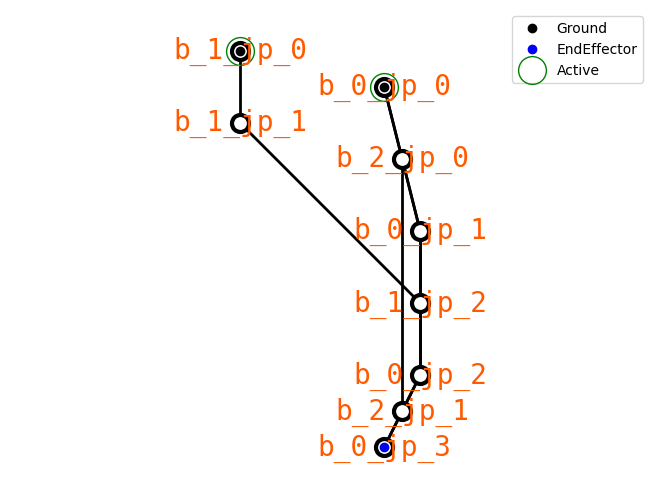

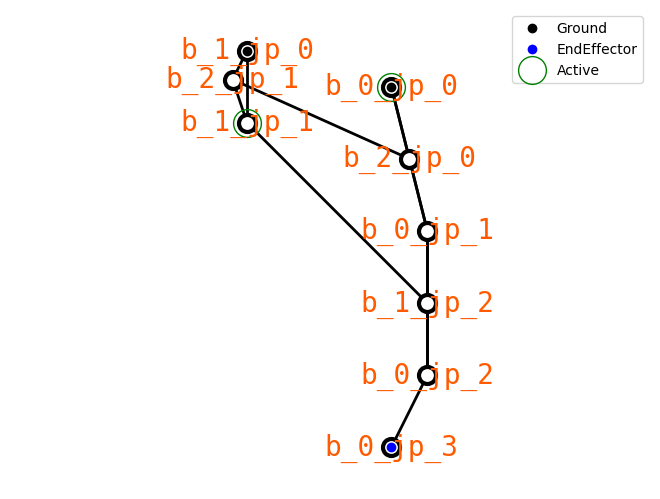

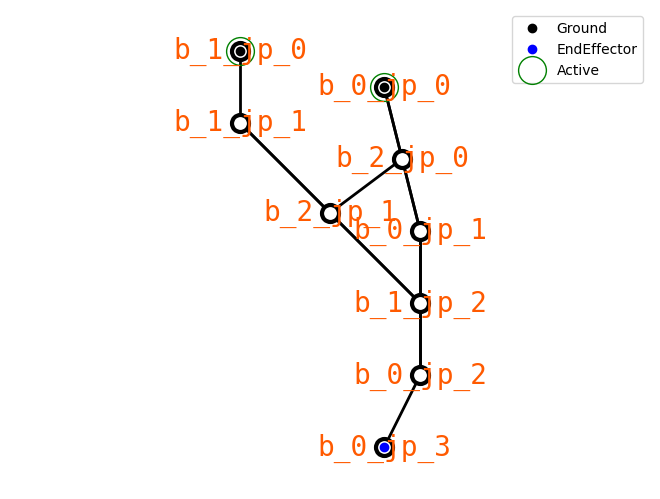

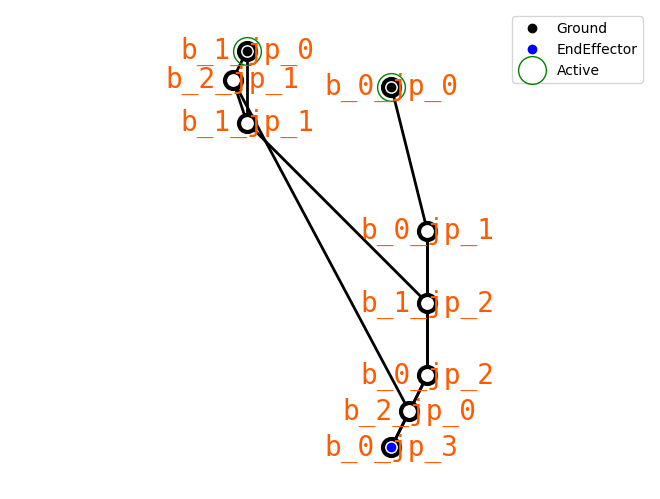

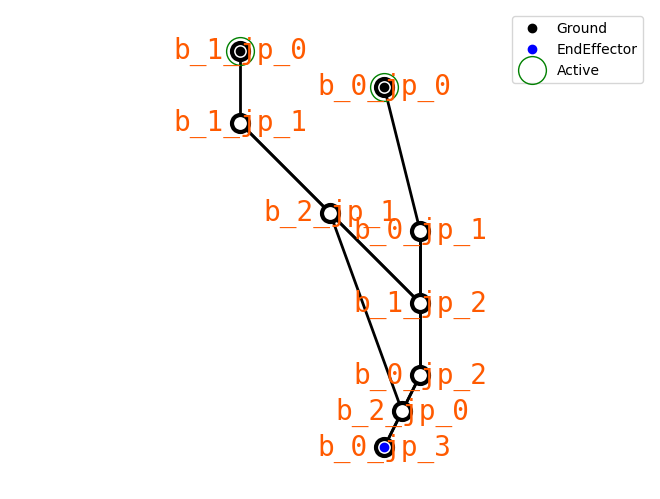

Triangle cycle detected in topology


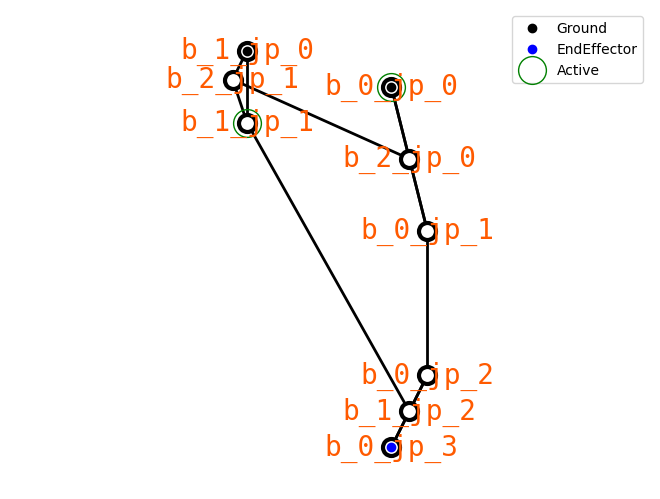

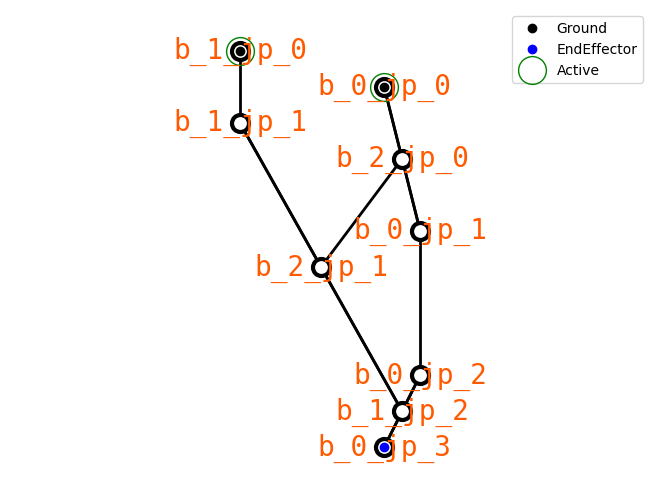

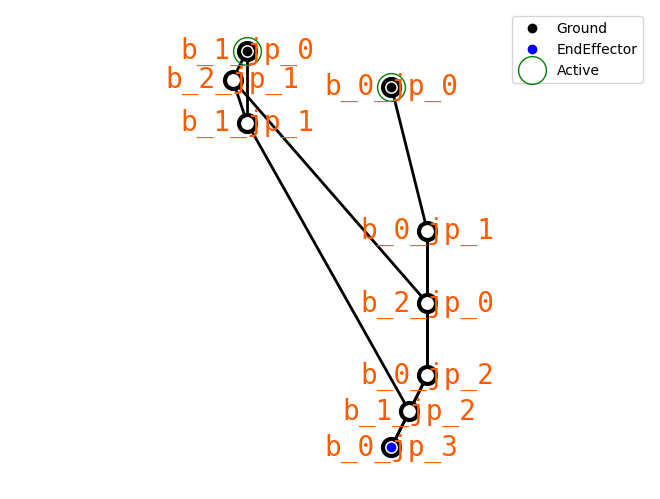

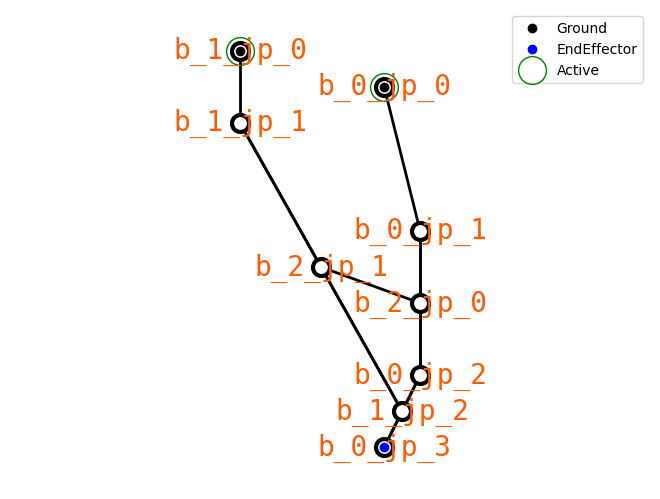

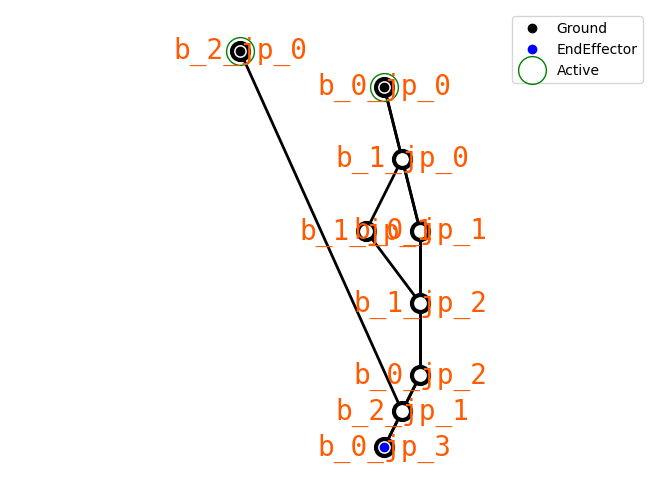

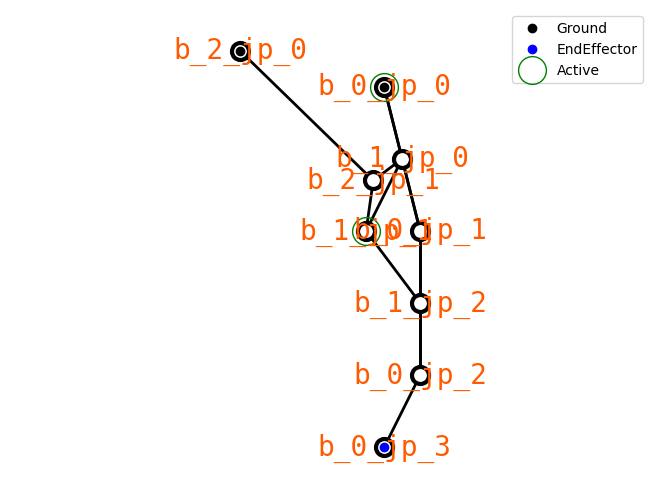

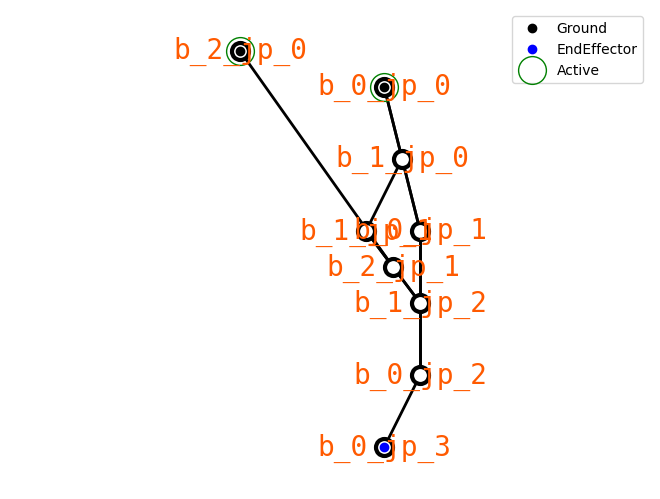

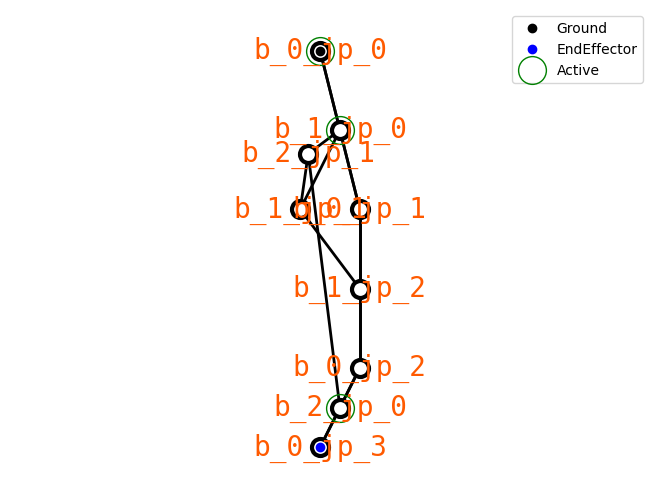

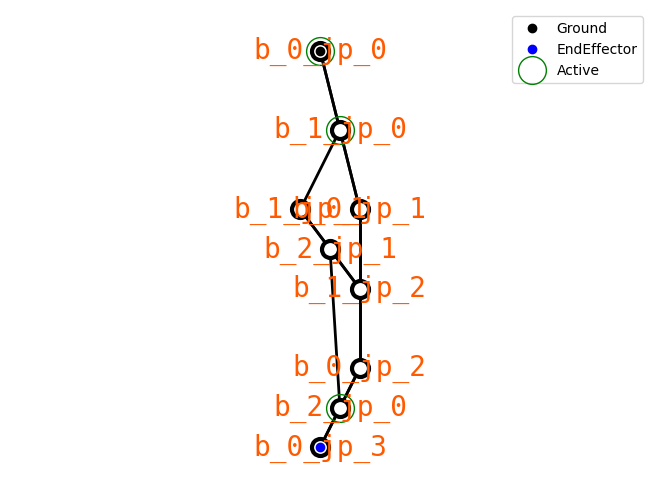

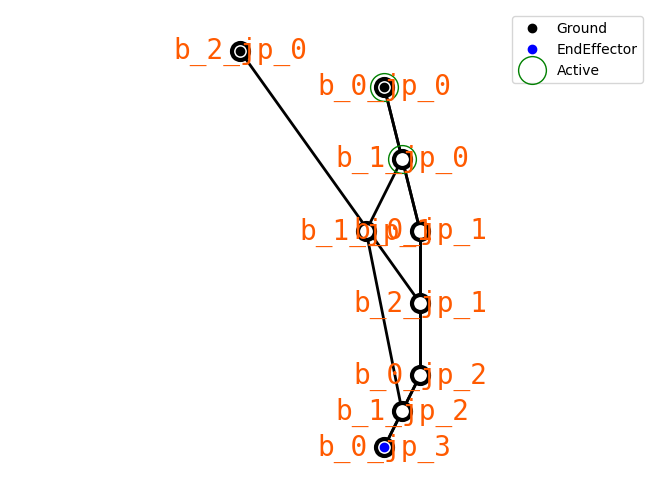

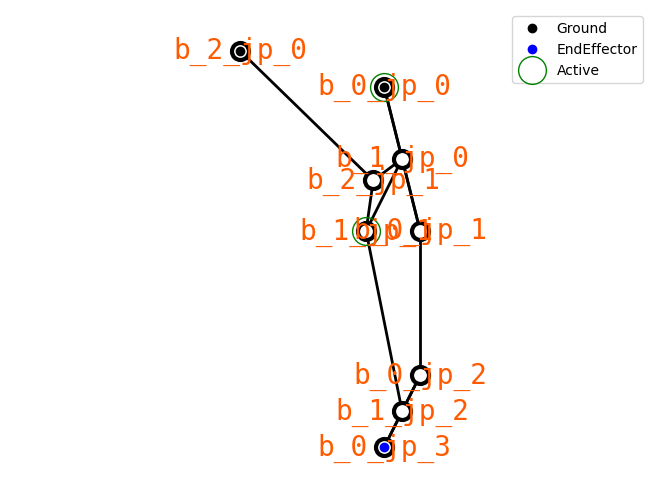

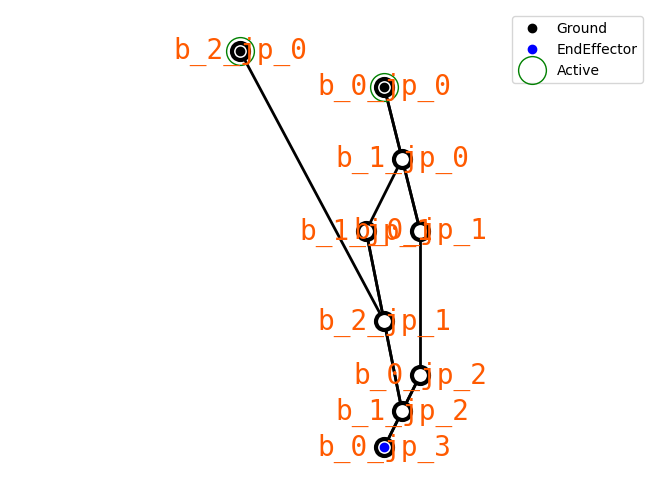

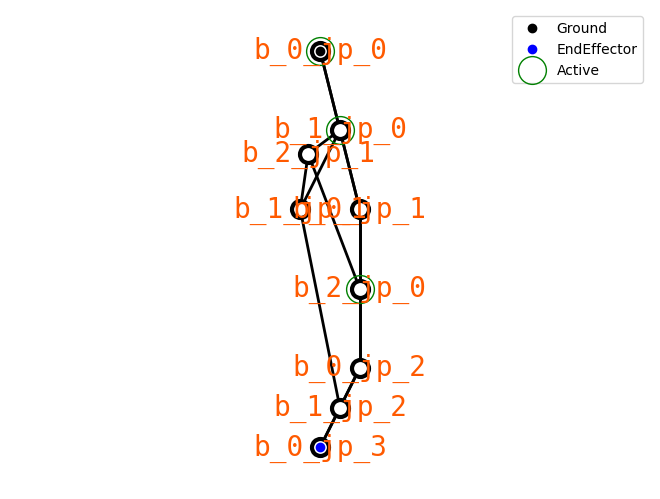

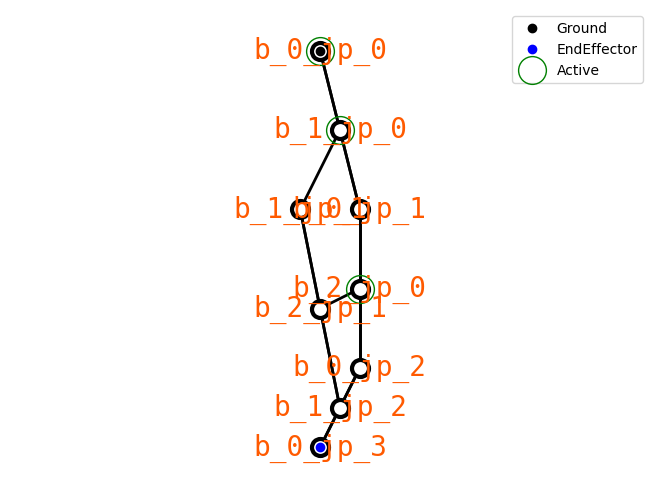

In [12]:
generator = Generator2DRotational()
joint = SchemeJoint(name="b_0_j_0", mutation_type=MutationType.ABSOLUTE, mutation_x=MutationCoordinate(
    freeze=0.0), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(freeze=0.0), active=True, attach_ground=True)
generator.add_joint(joint)
joint = SchemeJoint(name="b_0_j_1", mutation_type=MutationType.ABSOLUTE,
                    mutation_x=MutationCoordinate(mutation_origin=0.05, lower_bound=-0.1, upper_bound=0.1), mutation_y = MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.2, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(joint)
joint = SchemeJoint(name="b_0_j_2", mutation_type=MutationType.ABSOLUTE, mutation_x=MutationCoordinate(mutation_origin=0.05, lower_bound=-0.1, upper_bound=0.1), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.4, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(joint)
ee = SchemeEE(name="b_0_j_3", mutation_x=MutationCoordinate(freeze=0.0), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(freeze=-1))
generator.add_joint(ee)

scheme_connection = SchemeConnectionJoint(name="G",
                                            mutation_type=MutationType.ABSOLUTE,
                                            mutation_x = MutationCoordinate(mutation_origin=-0.2, upper_bound=0.1, lower_bound=-0.1), 
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=0.0, upper_bound=0.2),
                                        active=False, attach_ground=True, connected_to=(0,-1))
connection = GeneratorConnection(scheme_connection, start_open=(1,2), end_open=(), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="CJ_0",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE,
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(0, 0), dependent_shift=[-0.05, 0.0, 0.0])
connection = GeneratorConnection(scheme_connection, start_open=(1,2), end_open=(), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="CJ_1",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE, 
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(0, 1))
connection = GeneratorConnection(scheme_connection, start_open=tuple([2]), end_open=(1,2), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="CJ_2",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE, 
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(0, 2))
connection = GeneratorConnection(scheme_connection, start_open=tuple([2]), end_open=(1,2), connected=None)
generator.add_connection(connection)

generator.create_sub_branch()
joint = SchemeJoint(name="b_1_j_1", mutation_type=MutationType.RELATIVE, mutation_x=MutationCoordinate(mutation_origin=0.0, lower_bound=-0.1, upper_bound=0.1), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.1, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(joint, 1)


scheme_connection = SchemeConnectionJoint(name="BC_0",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE,
                                            mutation_x = MutationCoordinate(mutation_origin=-0.2, upper_bound=0.1, lower_bound=-0.1), 
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=0.0, upper_bound=0.2),
                                        active=False, attach_ground=False, connected_to=(1,0))
connection = GeneratorConnection(scheme_connection, start_open=(), end_open=tuple([2]), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="BC_1",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE,
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(1, 1), dependent_shift=[-0.05, 0.0, 0.0])
connection = GeneratorConnection(scheme_connection, start_open=(), end_open=tuple([2]), connected=None)
generator.add_connection(connection)

generator.create_sub_branch()

generator.build_all_topologies()
print(len(generator.topologies))

for topology in generator.topologies:
    manager = MutableGraphManager(topology)
    manager.build_graph()
    if manager.check_for_triangle_cycles():
        print("Triangle cycle detected in topology")
        continue
    manager.find_active_joints()
    manager.get_mutation_ranges()
    graph = manager.get_central_graph()
    draw_joint_point(graph)
    plt.show()

In [ ]:
cycles = nx.simple_cycles(graph)
for cycle in cycles:
    nx.draw(cycle)
    break

In [ ]:
triangles = nx.triangles(graph)
for key in triangles.keys():
    print(key, triangles[key])
    

In [ ]:
triangles = [cycle for cycle in nx.simple_cycles(graph) if len(cycle) == 4]
print("Triangles:", triangles[0])

In [17]:
1.0125**36*1000


1563.9438187272835